<a href="https://colab.research.google.com/github/Sam-eb/Modelos-1-2026-2/blob/feature%2Fexpansion-exploracion-datos/Proyecto_Modelos_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **El extraño caso del Titanic Espacial**

## **Introducción**

Seleccionamos el problema hipotético de predecir el resultado de una colisión espacial en la cual los pasajeros de una nave pudieron (o no) ser transportados a otra dimensión. Para solucionar este problema buscamos un modelo que, según ciertas entradas, pueda predecir si un pasajero fue transportado o no. Por esto, buscamos el desarrollo de un modelo de clasificación para nuestra variable objetivo `Transported` de tipo booleana.

Nuestros datos provienen de una competencia en Kaggle llamada Spaceship Titanic, a la cual se puede acceder desde el siguiente enlace:

https://www.kaggle.com/competitions/spaceship-titanic

In [80]:
import pandas as pd
import scipy
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.dummy import DummyClassifier
from scipy.stats.contingency import association
%matplotlib inline

## **Conjunto de datos**

En esta primera celda de código podemos ver que extraemos los datos de un archivo CSV y los almacenamos en la variable:
```python
data_set
```
Adicionalmente, podemos ver las primeras 5 entradas de nuestros datos.

In [81]:
data_set = pd.read_csv('https://raw.githubusercontent.com/Sam-eb/Modelos-1-2026-2/refs/heads/develop/Data_Set.csv')

In [82]:
data_set.head(5)

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


## **Exploración de los datos**

### Fase 1: Estructura General y Tipos de Datos

In [83]:
print (data_set.shape)


(8693, 14)


In [84]:
for c in data_set.columns:
    print ("%20s"%c, data_set[c].dtype)

         PassengerId object
          HomePlanet object
           CryoSleep object
               Cabin object
         Destination object
                 Age float64
                 VIP object
         RoomService float64
           FoodCourt float64
        ShoppingMall float64
                 Spa float64
              VRDeck float64
                Name object
         Transported bool


Podemos ver que nuestro conjunto de datos tiene un total de 8693 registros con 14 variables medidas. Dichas variables son de diversos tipos: numéricas como `Spa`, `VRDeck` o `Age`, así como categóricas tomando de ejemplo a `HomePlanet`, y hasta booleanas como `CryoSleep`.

### Fase 2: Análisis de Valores Faltantes
En las siguientes celdas podemos ver la cantidad y el porcentaje de valores perdidos durante la recuperación de los datos.

In [85]:
num_Na = data_set.isna().sum()
print("Número de valores perdidos por variable: \n")
num_Na

Número de valores perdidos por variable: 



PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
dtype: int64

In [86]:
print("\nPorcentaje de valores perdidos por variable: \n")
num_Na * 100 / data_set.shape[0]


Porcentaje de valores perdidos por variable: 



PassengerId     0.000000
HomePlanet      2.312205
CryoSleep       2.496261
Cabin           2.289198
Destination     2.093639
Age             2.059128
VIP             2.335212
RoomService     2.082135
FoodCourt       2.105142
ShoppingMall    2.392730
Spa             2.105142
VRDeck          2.162660
Name            2.300702
Transported     0.000000
dtype: float64

En nuestros registros vemos que hay valores perdidos o anotados como NaN. Estos no representan un problema debido a su cantidad (~2%), gracias a esto podemos, hasta ahora, podemos tener a todas las variables en consideración para ajustar el modelo.

In [87]:
print("La cantidad de pasajeros que NO fueron transportados a otra dimensión es de:\n", len(data_set[data_set.Transported == False]))
print("La cantidad de pasajeros que fueron transportados a otra dimensión es de:\n", len(data_set[data_set.Transported == True]))
print("La variable objetivo tiene una desviación estándar de:", data_set.Transported.std())
print("La variable objetivo tiene una media aritmética de:", data_set.Transported.mean())

La cantidad de pasajeros que NO fueron transportados a otra dimensión es de:
 4315
La cantidad de pasajeros que fueron transportados a otra dimensión es de:
 4378
La variable objetivo tiene una desviación estándar de: 0.5000156298104965
La variable objetivo tiene una media aritmética de: 0.5036236051995858


### Fase 3: Análisis de la Variable Objetivo y Variables Clave
Analizamos la distribución de nuestra variable objetivo `Transported` y la relación de otras variables numéricas y categóricas clave.

In [88]:
data_set.columns


Index(['PassengerId', 'HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'Age',
       'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck',
       'Name', 'Transported'],
      dtype='object')

In [89]:
data_set._get_numeric_data().describe().T

,count,mean,std,min,25%,50%,75%,max
Age,8514.0,28.827930,14.489021,0.0,19.0,27.0,38.0,79.0
RoomService,8512.0,224.687617,666.717663,0.0,0.0,0.0,47.0,14327.0
FoodCourt,8510.0,458.077203,1611.489240,0.0,0.0,0.0,76.0,29813.0
ShoppingMall,8485.0,173.729169,604.696458,0.0,0.0,0.0,27.0,23492.0
Spa,8510.0,311.138778,1136.705535,0.0,0.0,0.0,59.0,22408.0
VRDeck,8505.0,304.854791,1145.717189,0.0,0.0,0.0,46.0,24133.0


Podemos ver que todas las variables numéricas, a excepción de la edad, tienen una asimetría notable, es decir, la mayoría de pasajeros no hicieron gastos en el Titanic Espacial, y unos pocos hacen gastos de gran valor. Por esto una normalización no haría que los valores dejen de estar sesgados, es mejor optar por una transformación logarítmica (como `log1p`) para cambiar su distribución  y luego sí realizar una normalización.

In [90]:
# Contar cuántos pasajeros tienen exactamente 0 años
nro_bebes_cero = (data_set['Age'] == 0).sum()
print(f"Cantidad de pasajeros con 0 años (bebés): {nro_bebes_cero}\n")

# Crear rangos de edad para analizar la tasa de transportados
edad_temp = data_set[['Age', 'Transported']].dropna().copy()

# Definimos rangos
intervalos = [-1, 1, 6, 14, 29, 59, 100]
etiquetas = ['0-1 años', '2-6 años', '7-14 años', '15-29 años', '30-59 años','60+ años']
edad_temp['Rango_Edad'] = pd.cut(edad_temp['Age'], bins=intervalos, labels=etiquetas)

# Calcular porcentaje de transportados por rango de edad
tasa_por_edad = edad_temp.groupby('Rango_Edad', observed=False)['Transported'].mean().reset_index()
tasa_por_edad['Transported'] = tasa_por_edad['Transported'] * 100
tasa_por_edad.columns = ['Rango de Edad', '% Transportados']

display(tasa_por_edad)

Cantidad de pasajeros con 0 años (bebés): 178



,Rango de Edad,% Transportados
0,0-1 años,78.775510
1,2-6 años,70.748299
2,7-14 años,57.142857
3,15-29 años,48.344198
4,30-59 años,47.964072
5,60+ años,46.850394


Con respecto a la edad podemos ver que hay una tendencia importante en los bebés (0-1 años) y niños de primera infancia (2-6 años): en su mayoría, fueron transportados.

In [91]:
# Filtrar los pasajeros que tienen exactamente 0 años
bebes_cero = data_set[data_set['Age'] == 0]

# Definir las columnas de gastos a bordo
columnas_gastos = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

# Obtener estadísticas de gastos para los pasajeros de 0 años
resumen_gastos_bebes = bebes_cero[columnas_gastos].describe().T

print("Resumen de gastos para pasajeros con edad igual a 0:")
display(resumen_gastos_bebes)

# Verificar si hay algún registro con un gasto mayor a 0
total_con_gastos = (bebes_cero[columnas_gastos] > 0).any(axis=1).sum()
print(f"\nCantidad de 'bebés' que registran algún gasto > 0: {total_con_gastos}")

Resumen de gastos para pasajeros con edad igual a 0:


,count,mean,std,min,25%,50%,75%,max
RoomService,174.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
FoodCourt,176.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ShoppingMall,172.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Spa,175.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
VRDeck,173.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



Cantidad de 'bebés' que registran algún gasto > 0: 0


Para comprobar si las edades registradas en `0` correspondían a bebés reales o si eran datos erróneos/placeholders, analizamos los consumos en los servicios de lujo de la nave (`RoomService`, `FoodCourt`, `ShoppingMall`, `Spa` y `VRDeck`).

El análisis arrojó que el 100% de los pasajeros con edad 0 presenta gastos de exactamente 0 en todos los servicios. Esto confirma de manera sólida que estos registros corresponden genuinamente a bebés y no a un error en el llenado de los datos, validando su comportamiento diferenciado respecto a la variable objetivo `Transported` (donde registran una alta tasa del ~78%).

In [92]:
# cols = data_set._get_numeric_data().columns
# sns.set()
# sns.pairplot(data_set[cols])

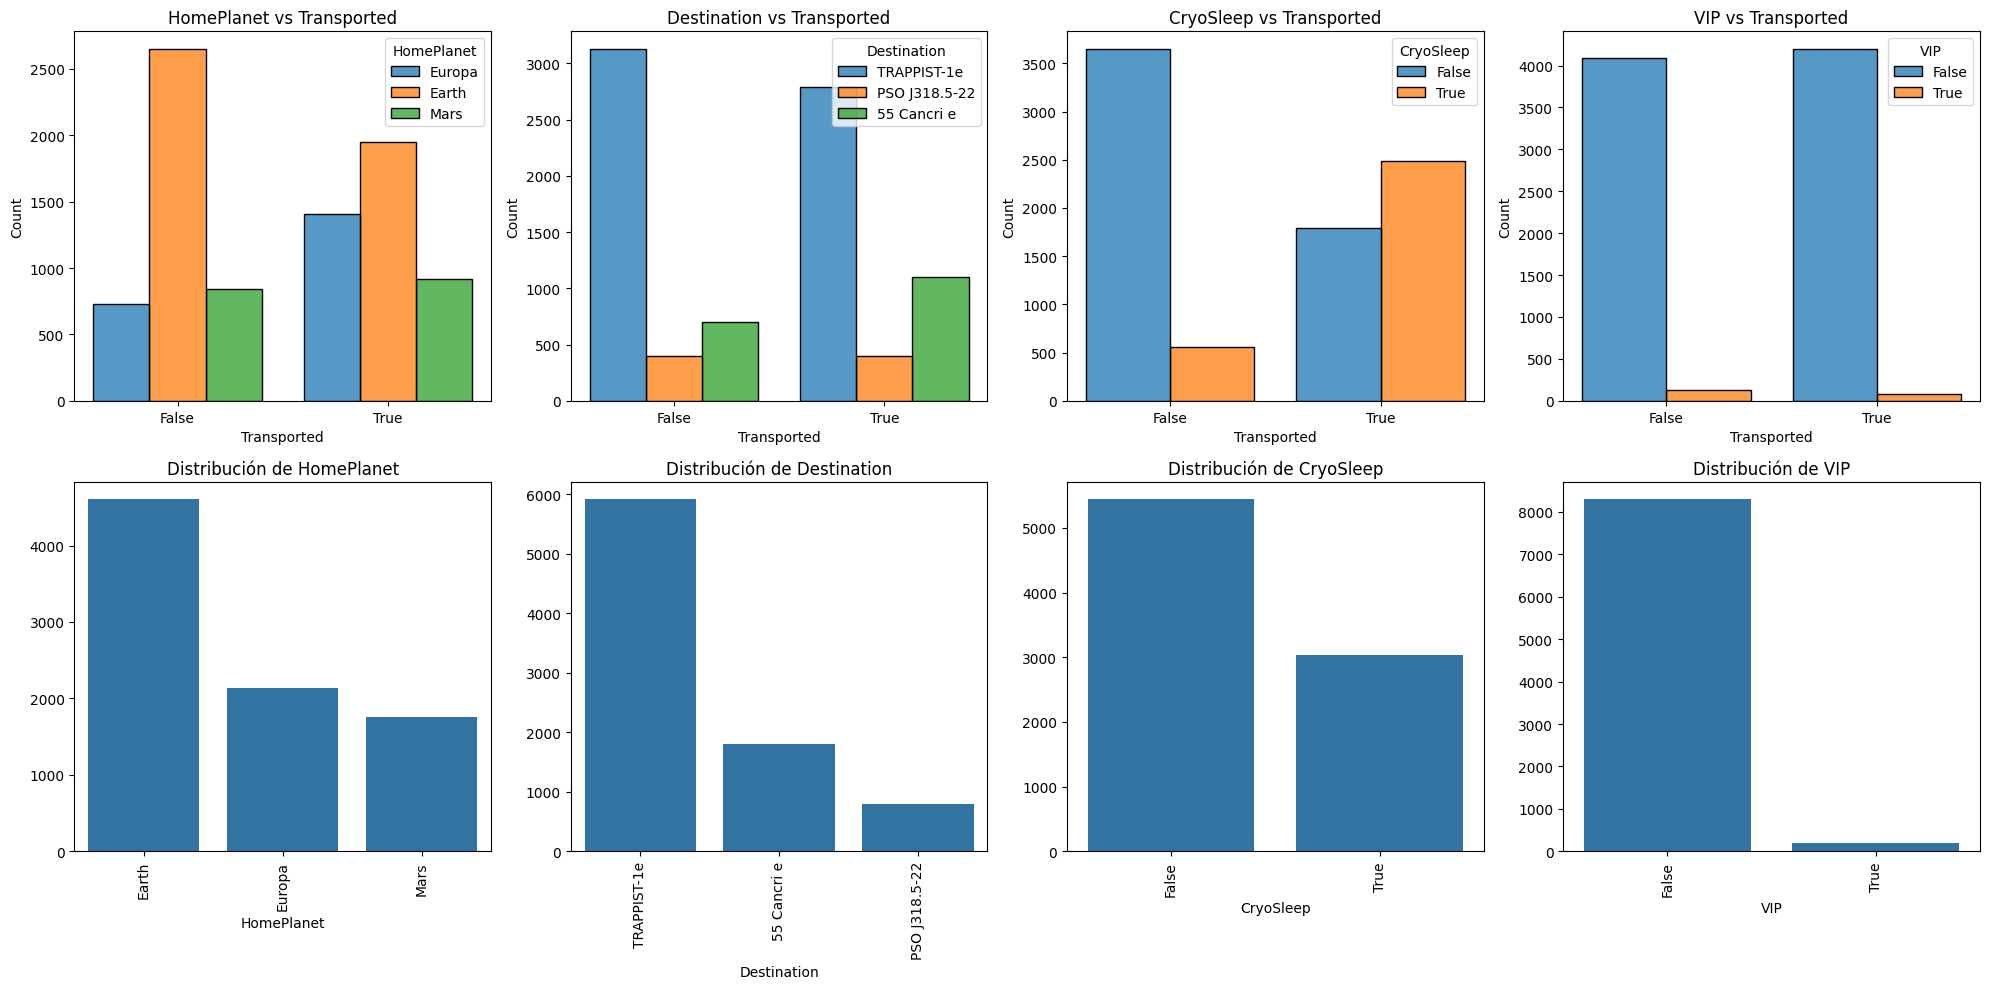

In [93]:
plt.figure(figsize=(20,10))
categorical_cols = ["HomePlanet", "Destination", "CryoSleep", "VIP"]

for i, c in enumerate(categorical_cols):
    # Gráfico de relación con la variable objetivo
    plt.subplot(2, 4, i+1)
    k = data_set[[c, "Transported"]].dropna().copy()
    k[c] = k[c].astype(str)  # Asegurar visualización categórica limpia
    k["Transported"] = k["Transported"].astype(str)

    sns.histplot(data=k, x="Transported", hue=c, multiple="dodge", shrink=0.8)
    plt.title(f"{c} vs Transported")

    # Gráfico de distribución de frecuencias
    plt.subplot(2, 4, i+5)
    vc = data_set[c].dropna().value_counts()
    sns.barplot(x=vc.index, y=vc.values)
    plt.title(f"Distribución de {c}")
    plt.xticks(range(len(vc)), vc.index, rotation="vertical")

plt.tight_layout()
plt.show()

Con estos 8 gráficos podemos observar:
La relación de `HomePlanet`, `Destination`, `CryoSleep` y `VIP` con `Transported` junto a la distribución de cada variable.

----

Del gráfico que contrasta `Transported` con `HomePlanet` podemos ver que, según la categoría, se puede establecer una tendencia. Por ejemplo, en Europa se aprecia una mayor proporción de pasajeros transportados, mientras que en Earth ocurre el caso contrario. Finalmente, Mars no representa una diferencia notable.

---

En el gráfico de `Transported` vs `Destination`, las variables tienen comportamientos muy similares entre ellas, tanto en los transportados como en los que no, lo cual imposibilita establecer un umbral diferenciable a simple vista.

---

En el gráfico de `Transported` vs `CryoSleep`, se aprecia una diferencia sumamente marcada: aquellos pasajeros en estado de animación suspendida (CryoSleep = True) muestran una proporción significativamente mayor de haber sido transportados, indicando una fuerte relación con la variable objetivo.

---

En el gráfico de `Transported` vs `VIP`, las variables tienen comportamientos muy similares tanto en los transportados como en los que no, mostrando que la categoría VIP no representa una diferencia notable en el resultado final.

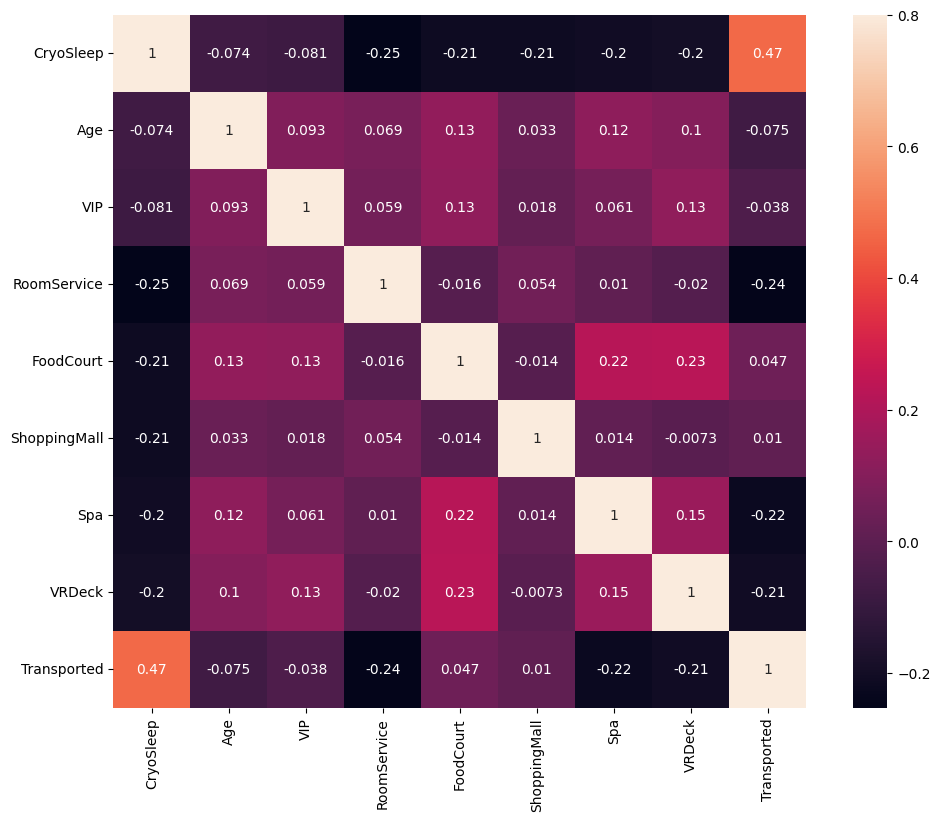

In [94]:
data_set['VIP'] = pd.to_numeric(data_set['VIP'])
data_set['CryoSleep'] = pd.to_numeric(data_set['CryoSleep'])
corrmat = data_set._get_numeric_data().corr()
f, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corrmat,annot = True, vmax=.8, square=True);

In [95]:
cols_numericas = data_set._get_numeric_data().columns

resultados = []
for i, col1 in enumerate(cols_numericas):
    for col2 in cols_numericas[i+1:]:
        datos = data_set[[col1, col2]].dropna()
        if len(datos) > 1:
            r, p = scipy.stats.pearsonr(datos[col1], datos[col2])
            resultados.append({'Variable 1': col1, 'Variable 2': col2, 'r': r, 'p_value': p})

resultados_df = pd.DataFrame(resultados)
display(resultados_df)

,Variable 1,Variable 2,r,p_value
0,CryoSleep,Age,-0.074273,1.251636e-11
1,CryoSleep,VIP,-0.081402,1.185867e-13
2,CryoSleep,RoomService,-0.252396,9.461247e-121
3,CryoSleep,FoodCourt,-0.211510,1.536799e-84
4,CryoSleep,ShoppingMall,-0.212514,3.830636e-85
5,CryoSleep,Spa,-0.203991,1.161235e-78
6,CryoSleep,VRDeck,-0.198857,9.663653e-75
7,CryoSleep,Transported,0.468645,0.000000e+00
8,Age,VIP,0.092819,2.216081e-17
9,Age,RoomService,0.068723,3.380023e-10


Se utilizará un umbral de correlación en $|r| \ge 0.2$ porque con un dataset de más de $8.000$ datos, cualquier relación superior a este valor podría contener significancia práctica, y no ser ruido aleatorio. Aún así aclaramos que haciendo uso de *"pearson"* buscamos la existencia de relaciones, a pesar de que puedan ser insignificativas, esto mediante pruebas de hipótesis haciendo uso del $p-value$, teniendo como criterio un $p<0.05$. Con esta prueba pudimos comprobar que entre muchas variables existe una relación (esto sucede por el tamaño de nuestra muestra), pero no por ello se tendran en cuenta.

Podemos resaltar que `ShoppingMall` es la única variable que no tiene una relacion con `Transported` ya que tiene un p-value de 0.35

In [96]:
# Filtrar parejas con correlación mayor o igual a 0.2 en valor absoluto (obvio excluyendo la diagonal)
pairs = corrmat.unstack().reset_index()
pairs.columns = ['Variable 1', 'Variable 2', 'Correlacion']
pairs = pairs[pairs['Variable 1'] < pairs['Variable 2']] # Evitar duplicados y diagonal
significant_corr = pairs[pairs['Correlacion'].abs() >= 0.2].sort_values(by='Correlacion', ascending=False)
display(significant_corr)

,Variable 1,Variable 2,Correlacion
8,CryoSleep,Transported,0.468645
43,FoodCourt,VRDeck,0.227995
42,FoodCourt,Spa,0.221891
6,CryoSleep,Spa,-0.203991
79,Transported,VRDeck,-0.207075
4,CryoSleep,FoodCourt,-0.211510
5,CryoSleep,ShoppingMall,-0.212514
62,Spa,Transported,-0.221131
35,RoomService,Transported,-0.244611
3,CryoSleep,RoomService,-0.252396


Después del análisis de correlaciones, nos enfocamos en aquellas relaciones que superan el umbral establecido, las cuales resultan ser las más significativas dentro del conjunto de datos:

*   **CryoSleep y Transported ($r = 0.47$):** Presenta la correlación positiva más fuerte, lo que sugiere que los pasajeros en estado de CryoSleep tuvieron una mayor probabilidad de ser transportados.
*   **RoomService y CryoSleep ($r = -0.25$) / Transported ($r = -0.24$):** El uso de RoomService se correlaciona negativamente tanto con estar en CryoSleep (lo cual es lógico, al estar dormidos no consumen servicios) como con haber sido transportados.
*   **Spa y Transported ($r = -0.22$) / CryoSleep ($r = -0.20$):** Al igual que RoomService, el gasto en Spa tiene una relación negativa con ambas variables.
*   **VRDeck y Transported ($r = -0.21$) / CryoSleep ($r = -0.20$):** Sigue el mismo patrón negativo asociado al consumo o gasto a bordo frente al estado de suspensión y al transporte final.
*   **FoodCourt y CryoSleep ($r = -0.21$):** Relación negativa que resulta consistente con el hecho de no consumir alimentos mientras se descansa en CryoSleep.

Cabe señalar que Age no aparece en este listado, ya que su relación lineal con Transported es débil ($r = -0.075$). Sin embargo, más arriba en el notebook se evidencia una relación fuerte para los pasajeros cuya edad está entre 0 y 6 años.

Para buscar la fuerza de la relación vamos a tratar a la edad por rangos, los mismos que usamos más arriba, para ver si su Cramér's V pasa nuestro criterio

In [97]:
tabla_edad = pd.crosstab(edad_temp['Rango_Edad'], edad_temp['Transported'])
v_edad = association(tabla_edad, method='cramer')
print(f"Rango_Edad: Cramér's V = {v_edad:.4f}")

Rango_Edad: Cramér's V = 0.1342


Vemos que no pasa nuestro criterio ni cambiando la prueba con otra perspectiva, por ello la tenemos en consideración para ser eliminada.

In [98]:
ccols = [i for i in data_set.columns if not i in data_set._get_numeric_data()]
print (ccols)

['PassengerId', 'HomePlanet', 'Cabin', 'Destination', 'Name']


In [99]:
for c in ccols:
    print ("%10s"%c, np.unique(data_set[c].dropna()))

PassengerId ['0001_01' '0002_01' '0003_01' ... '9279_01' '9280_01' '9280_02']
HomePlanet ['Earth' 'Europa' 'Mars']
     Cabin ['A/0/P' 'A/0/S' 'A/1/S' ... 'T/2/P' 'T/2/S' 'T/3/P']
Destination ['55 Cancri e' 'PSO J318.5-22' 'TRAPPIST-1e']
      Name ['Aard Curle' 'Aarjel Jaff' 'Aarjel Rhuba' ... 'Zosmas Mormonized'
 'Zubeneb Flesping' 'Zubeneb Pasharne']


In [100]:
for c in data_set.columns:
    print(data_set[c].value_counts())

PassengerId
0001_01    1
0002_01    1
0003_01    1
0003_02    1
0004_01    1
          ..
9276_01    1
9278_01    1
9279_01    1
9280_01    1
9280_02    1
Name: count, Length: 8693, dtype: int64
HomePlanet
Earth     4602
Europa    2131
Mars      1759
Name: count, dtype: int64
CryoSleep
0.0    5439
1.0    3037
Name: count, dtype: int64
Cabin
G/734/S     8
F/1194/P    7
B/201/P     7
G/981/S     7
G/109/P     7
           ..
E/56/P      1
A/98/P      1
G/1499/S    1
G/1500/S    1
D/252/P     1
Name: count, Length: 6560, dtype: int64
Destination
TRAPPIST-1e      5915
55 Cancri e      1800
PSO J318.5-22     796
Name: count, dtype: int64
Age
24.0    324
18.0    320
21.0    311
19.0    293
23.0    292
       ... 
75.0      4
79.0      3
78.0      3
76.0      2
77.0      2
Name: count, Length: 80, dtype: int64
VIP
0.0    8291
1.0     199
Name: count, dtype: int64
RoomService
0.0       5577
1.0        117
2.0         79
3.0         61
4.0         47
          ... 
6899.0       1
1954.0       1

En esta celda de código podemos ver algunos de los valores únicos en las variables no numéricas. Aquí evidenciamos que `Name` tiene 8473 valores diferentes, lo cual la hace candidata a ser eliminada. Caso diferente es el de `Cabin` y `PassengerId`, ya que estas dos variables tienen información adicional. `PassengerId` nos puede dar información sobre las personas que iban juntas, porque esta variable tiene la estructura de grupo y número dentro del grupo. `Cabin`, por su parte, tiene la estructura `deck/number/side`, donde `side` solo tiene dos posibles valores: P, de babor, y S, de estribor (en inglés, Port y Starboard).

Se podría considerar la posibilidad de extraer los apellidos de la variable `Name`, pero vemos esto como una pérdida de tiempo, ya que la única funcionalidad sería reducir su cardinalidad y buscar una relación entre las personas con el mismo apellido, asumiendo que son parte del mismo grupo. Sin embargo, para ello ya contamos con `Group`, que extraemos de `PassengerId`. Además, que dos personas tengan el mismo apellido no significa que vayan a viajar juntas.

In [101]:
data_set[["Deck","Cabin_Num","Side"]] = data_set["Cabin"].str.split("/", expand= True)
data_set['Cabin_Num'] = pd.to_numeric(data_set['Cabin_Num'])
data_set["Group"] = data_set["PassengerId"].str[0:4]
tamano_grupo = data_set['Group'].value_counts()
data_set['Group_Size'] = data_set['Group'].map(tamano_grupo)

Dividimos la cabina en `Deck`, `Cabin_Num` y `Side`. De esta forma podemos realizar un análisis por separado de cada componente, lo que hace más comprensible nuestro trabajo.

Asimismo, separamos los grupos de `PassengerId` y los almacenamos en `Group`. Luego calculamos el tamaño de los grupos para analizar si existe un mayor número de pasajeros transportados en grupos grandes o pequeños.

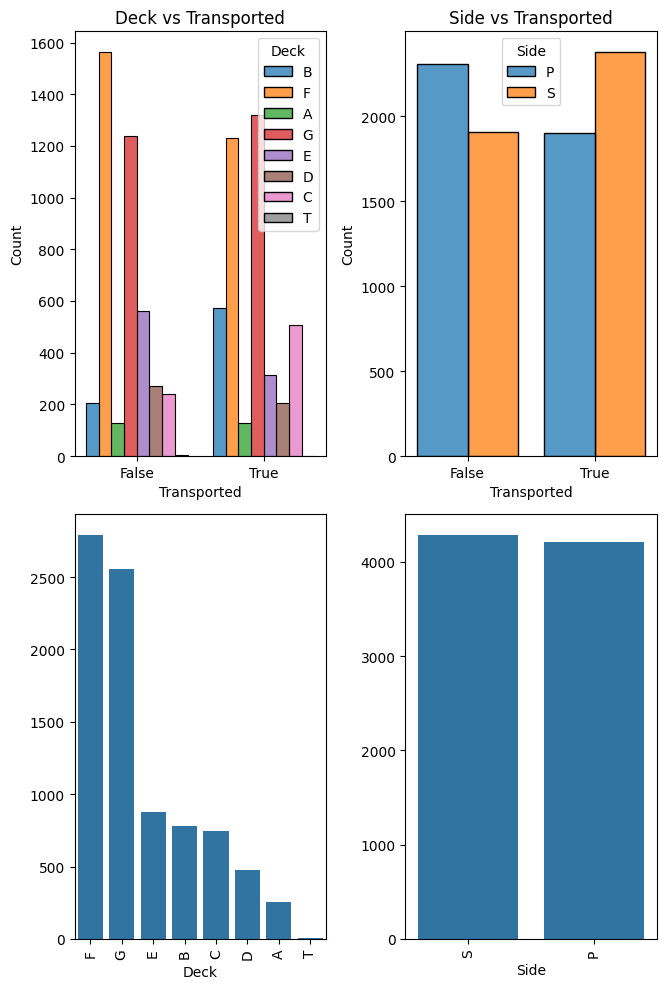

In [102]:
categorical_cols = ["Deck", "Side"]

plt.figure(figsize=(20,10))
for i, c in enumerate(categorical_cols):
    plt.subplot(2, 6, i+1)
    k = data_set[[c, "Transported"]].dropna().copy()
    k[c] = k[c].astype(str)
    k["Transported"] = k["Transported"].astype(str)
    sns.histplot(data=k, x="Transported", hue=c, multiple="dodge", shrink=0.8)
    plt.title(f"{c} vs Transported")

    plt.subplot(2, 6, i+7)
    vc = data_set[c].dropna().value_counts()
    sns.barplot(x=vc.index, y=vc.values)
    plt.xticks(range(len(vc)), vc.index, rotation="vertical")

plt.tight_layout()
plt.show()

A simple vista vemos que la variable `Deck` tiende a estar más concentrada en la cubierta F, `Side` tiene una distribución balanceada, es decir, no se ve mucha diferencia ente Estribor y Babor.

En este mismo gráfico tenemos la distribución de ambas variables con respecto a `Transported`.

---

Vemos que cada Cubierta tiene una relación distinta con `Transported`, por ello intentaremos ver si tiene una relación fuerte, haciendo uso de Cramer's V ya que es una variable categórica.

---

Respecto a `Side` podemos ver que hay más transportados en estribor que no transportados, y pasa lo contrario en babor. También vemos necesario el análisis de correlación.

In [103]:
from scipy.stats.contingency import association

for c in ["Deck", "Side", "HomePlanet", "Destination"]:
    tabla = pd.crosstab(data_set[c], data_set['Transported'])
    v = association(tabla, method='cramer')
    print(f"{c}: Cramér's V = {v:.4f}")

Deck: Cramér's V = 0.2149
Side: Cramér's V = 0.1038
HomePlanet: Cramér's V = 0.1956
Destination: Cramér's V = 0.1118


Podemos ver que `Deck` tiene un Cramér's V de 0.2149, valor suficiente para cumplir nuestro criterio de $V > 0.2$. Por otro lado, `Side` no lo cumple, ya que su Cramér's V no es suficientemente grande.

En la celda anterior calculamos también la asociación de `HomePlanet` y `Destination` con `Transported`. Observamos que ambas quedan por debajo de nuestro criterio, aunque por muy poco. Debido a que existen valores `NaN`, consideraremos conservarlas, ya que podrían contener información significativa.

In [104]:
from scipy.stats import pointbiserialr

datos = data_set[['Group_Size', 'Transported']].dropna()
r, p = pointbiserialr(datos['Transported'].astype(int), datos['Group_Size'])
print(f"Group_Size: r = {r:.4f}, p = {p:.6f}")

Group_Size: r = 0.0826, p = 0.000000


También tenemos el tamaño del grupo, que presenta muchas categorías, por lo que revisaremos su Cramér's V.

In [105]:
tabla = pd.crosstab(data_set['Group_Size'], data_set['Transported'])
v = association(tabla, method='cramer')
print(f"Group_Size (categórico): Cramér's V = {v:.4f}")

Group_Size (categórico): Cramér's V = 0.1293


Tampoco vemos una relación fuerte, según nuestro criterio.

Ahora probaremos la última sección que separamos de `Cabin`, `Cabin_Num`

In [106]:
datos = data_set[['Cabin_Num', 'Transported']].dropna()
r, p = pointbiserialr(datos['Transported'].astype(int), datos['Cabin_Num'])
print(f"Cabin_Num: r = {r:.4f}, p = {p:.6f}")

Cabin_Num: r = -0.0451, p = 0.000032


Vemos que es significativa, pero no tiene un valor r suficiente para sobrepasar nuestro criterio.

### Fase 4: Decisiones finales

Hagamos un resumen de las decisiones tomadas para cada variable:


**PassengerId:** Lo descartamos por sí solo debido a su gran cardinalidad. Gracias a su estructura, pudimos extraer las variables `Group` y `Group_Size`.

**Group:** Aunque tiene una cardinalidad menor que `PassengerId`, aún sigue siendo muy grande y no aportaría información suficiente sobre la variable objetivo, por lo que decidimos eliminarla.

**Group_Size:** Esta variable ya no presenta problemas de cardinalidad, pero su Cramér's V no es suficiente para considerarla una variable con significancia práctica, por lo que se elimina.

**HomePlanet:** A pesar de estar por debajo de nuestro criterio de significancia práctica, la vamos a conservar. Durante las próximas transformaciones y al contrastarla con el modelo, decidiremos si eliminarla definitivamente o si, por el contrario, aporta información útil.

**CryoSleep:** La conservamos porque es la variable que presenta la mayor correlación con nuestra variable objetivo; sería inapropiado eliminarla.

**Cabin:** Por su cardinalidad se elimina, pero a partir de ella creamos las variables `Deck`, `Cabin_Num` y `Side`.

**Deck:** La conservamos, dado que superó nuestro criterio de significancia práctica.

**Cabin_Num:** Observamos que tiene una significancia estadística alta (presenta un $p$-value de 0.000032), pero su correlación no supera el umbral. Por la naturaleza de la variable, preferimos eliminarla.

**Side:** La eliminamos porque no supera nuestro criterio de significancia práctica. Aunque en el gráfico parece tener una relación posiblemente fuerte, esta idea no se respalda con pruebas numéricas. La relación visual puede explicarse por el tamaño de la muestra: incluso una correlación pequeña puede parecer fuerte.

**Destination:** Utilizamos el Cramér's V para buscar una relación que no se apreciara a simple vista en la gráfica. Como no superó nuestro criterio, decidimos eliminarla.

**Age:** Aunque su Cramér's V no supera nuestro criterio de significancia práctica, preferimos conservarla debido a los hallazgos iniciales, que muestran una relación entre los pasajeros de 0 a 6 años y `Transported`. Es posible que la relación no sea lineal y que un algoritmo pueda aprovecharla.

**VIP:** La eliminamos porque ni el gráfico ni las pruebas numéricas muestran una relación fuerte.

**RoomService:** Supera nuestro umbral, por lo que la conservamos.

**FoodCourt:** La eliminamos porque no presenta una correlación que supere nuestro criterio. Además, debido a la asimetría de los datos, no parece necesario conservarla.

**ShoppingMall:** Durante la prueba del $p$-value no demostró siquiera tener significancia estadística, por lo que la eliminamos y no la consideramos, salvo que necesitemos más variables.

**Spa:** Supera nuestro umbral, por lo que la conservamos.

**VRDeck:** Supera nuestro umbral, por lo que la conservamos.

**Name:** La eliminamos por su cardinalidad.

**Transported:** Al ser la variable objetivo, obviamente la conservamos.

## **Separación de entrenamiento y prueba**

In [107]:
from sklearn.model_selection import StratifiedGroupKFold

# 1. Objetivo y vector de agrupamiento
y = data_set["Transported"].astype(int)
groups = data_set["Group"]

# 2. Separación: 5 pliegues estratificados y agrupados; el primero es la prueba (~20%)
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=67)
train_idx, test_idx = next(sgkf.split(data_set, y, groups=groups))

# 3. Quedarse solo con las 7 variables finales y crear copias independientes
features = ["HomePlanet", "CryoSleep", "Deck", "Age",
            "RoomService", "Spa", "VRDeck"]

X_train = data_set.iloc[train_idx][features].copy()
X_test = data_set.iloc[test_idx][features].copy()
y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()
groups_train = groups.iloc[train_idx].copy()

En la celda anterior separamos el conjunto de datos en un 80 % para entrenamiento y un 20 % para prueba (aproximadamente 6950 y 1740 registros). Para la separación usamos `StratifiedGroupKFold`. Esta separación se realiza **antes** de cualquier imputación, de modo que esas transformaciones se ajusten únicamente con los datos de entrenamiento.

Después de separar, conservamos solo las 7 variables definidas en la Fase 4 de la exploración: `HomePlanet`, `CryoSleep`, `Deck`, `Age`, `RoomService`, `Spa` y `VRDeck`. La variable `Group` (extraída de `PassengerId`) fue usada únicamente como vector de agrupamiento para dividir y por lo tanto no forma parte de las variables del modelo.

### Por qué se hizo así

**1. Por qué separamos antes de transformar.** El conjunto de prueba debe simular pasajeros nuevos que el modelo nunca ha visto. Si se calcularamos medianas, medias o categorías con todos los datos antes de separar, el modelo recibiría información del conjunto de prueba y la métrica podría salir inflada.

**2. Por qué 80/20.** Con más de 8000 registros, un 20 % da una prueba suficientemente grande para que la estimación final sea estable sin quitarle demasiados datos al entrenamiento.

**3. Por qué agrupar (`Group`).** Los integrantes de un mismo grupo tienden a compartir características como el planeta de origen o la cubierta, por lo tanto su resultado en `Transported` se parece más de lo esperado por azar. Esto es importante pues si un grupo llegara a quedar repartido entre entrenamiento y prueba, el modelo se evaluaría con pasajeros muy parecidos a los que ya vio. 

**4. Cómo los agrupamos.** Utilizando el método de sklearn `StratifiedGroupKFold`. Este método divide los datos en k folds o pliegues, en nuestro caso 5, donde cada pliegue contiene aproximadamente el 20 % de los datos y cada registro aparece en la prueba exactamente una vez a lo largo de los k pliegues. Luego recibe un vector que indica a qué grupo pertenece cada registro y asigna cada grupo completo a un solo pliegue. En nuestro caso el vector es `Group`, extraído de `PassengerId`, que identifica a los pasajeros que viajaban juntos. Esto es para que ningun grupo quede repartido entre entrenamiento y test. Además intenta que cada pliegue conserve la misma proporción de la variable objetivo que el conjunto completo. Aquí busca que en cada pliegue haya cerca de un 50 % de transportados.

**5. Por qué `random_state=67`.** Es la semilla (similar al `random.seed()`) para que cualquier integrante del equipo obtenga exactamente la misma separación y los resultados sean reproducibles.

In [108]:
# 4. Verificaciones
print("Entrenamiento:", X_train.shape, f"({len(X_train) / len(data_set) * 100:.1f}%)", "| Prueba:", X_test.shape, f"({len(X_test) / len(data_set) * 100:.1f}%)")
print(f"Proporción de transportados -> train: {y_train.mean():.3f} | test: {y_test.mean():.3f}")
print("Grupos compartidos entre train y test:",
      len(set(groups_train) & set(groups.iloc[test_idx])))

Entrenamiento: (6954, 7) (80.0%) | Prueba: (1739, 7) (20.0%)
Proporción de transportados -> train: 0.504 | test: 0.504
Grupos compartidos entre train y test: 0


En la celda de código anterior se realizan las siguientes verificaciones:

- Los tamaños de entrenamiento y prueba (aprox. 80 % y 20 %).
- La proporción de transportados en cada conjunto, que debe ser cercana entre sí y a 0.50
- La cantidad de grupos compartidos entre entrenamiento y prueba, que debe ser 0

A continuación definimos la estrategia que será útil para la evaluación de los modelos.

Importamos `StratifiedKFold` para dividir el conjunto de entrenamiento en 5 partes, conservando en cada una una proporción de clases similar a la del conjunto original. También usamos `cross_val_score`, que entrenará y evaluará cada modelo en los distintos pliegues y devolverá una puntuación por cada partición.

La semilla `SEED = 67` permite que las divisiones sean reproducibles. De esta forma, cualquier integrante del equipo podrá obtener las mismas particiones y comparar los modelos bajo las mismas condiciones.

La validación cruzada se realizará únicamente sobre `X_train` y `y_train`. El conjunto `X_test` permanecerá reservado para la evaluación final del modelo seleccionado.

In [109]:
from sklearn.model_selection import cross_val_score

SEED = 67
cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)

## **Preparación de los datos**


Primero vamos a borrar los valores perdidos o que nos llegaron como Nan.

Para esto usaremos la siguiente estrategia:

Para HomePlanet y Deck vamos a usar la moda y con este valor reemplazamos lo perdido.

Luego podemos rellenar los NaN en las variables que representan gastos cuyo valor de CryoSleep sea True, ya que si están dormidos no pueden realizar gastos. Y aplicamos la misma lógica pero al revez, ya que si un pasajero hace gastos es porque no está dormido.

Luego rellenamos el resto de valores perdidos de CryoSleep con la moda.

Para Age hacemos un sampleo con una distribución normal.

Y para rellenar el resto de valores en NaN de las variables que representan gastos usamos la mediana.

In [110]:
X_train.HomePlanet = X_train.HomePlanet.fillna(X_train.HomePlanet.mode()[0])
X_test.HomePlanet = X_test.HomePlanet.fillna(X_train.HomePlanet.mode()[0])
X_train.Deck = X_train.Deck.fillna(X_train.Deck.mode()[0])
X_test.Deck = X_test.Deck.fillna(X_train.Deck.mode()[0])


gastos = ["RoomService","Spa","VRDeck"]
for gasto in gastos:
    X_train.loc[X_train.CryoSleep == True,gasto] = X_train.loc[X_train.CryoSleep == True,gasto].fillna(0)
    X_test.loc[X_test.CryoSleep == True,gasto] = X_test.loc[X_test.CryoSleep == True,gasto].fillna(0)

mask = X_train['CryoSleep'].isna() & (X_train[gastos].sum(axis=1, skipna=True) > 0)
X_train.loc[mask, 'CryoSleep'] = 0
mask = X_test['CryoSleep'].isna() & (X_test[gastos].sum(axis=1, skipna=True) > 0)
X_test.loc[mask, 'CryoSleep'] = 0

X_train.CryoSleep = X_train.CryoSleep.fillna(X_train.CryoSleep.mode()[0])
X_test.CryoSleep = X_test.CryoSleep.fillna(X_train.CryoSleep.mode()[0])


media_Age = X_train.Age.mean()
std_Age = X_train.Age.std()
num_nan = X_train.Age.isna().sum()
num_nan_test = X_test.Age.isna().sum()

np.random.seed(67)
edades_reemplazo_test = np.random.normal(media_Age, std_Age, num_nan_test)
edades_reemplazo_test = np.clip(edades_reemplazo_test, 0, None)

edades_reemplazo = np.random.normal(media_Age,std_Age,num_nan)
edades_reemplazo = np.clip(edades_reemplazo, 0, None)

X_train.loc[X_train.Age.isna(), 'Age'] = edades_reemplazo
X_test.loc[X_test.Age.isna(), 'Age'] = edades_reemplazo_test

for gasto in gastos:
    mediana = X_train[gasto].median()
    X_train[gasto] = X_train[gasto].fillna(mediana)
    X_test[gasto] = X_test[gasto].fillna(mediana)

podemos ver como tanto en train como en test ya no hay valores nulos

In [111]:
num_Na = X_train.isna().sum()
print("Número de valores perdidos por variable: \n")
num_Na

Número de valores perdidos por variable: 



HomePlanet     0
CryoSleep      0
Deck           0
Age            0
RoomService    0
Spa            0
VRDeck         0
dtype: int64

In [112]:
num_Na = X_test.isna().sum()
print("Número de valores perdidos por variable: \n")
num_Na

Número de valores perdidos por variable: 



HomePlanet     0
CryoSleep      0
Deck           0
Age            0
RoomService    0
Spa            0
VRDeck         0
dtype: int64

Ya con los valores reparados vamos a aplicar una transformación logaritmica sobre los datos que representan gastos, de esta forma suavizamos la cola en sus distribuciones, asi la distribución es la misma solo que los valores mayores a 0 no son tan lejanos.

In [113]:
X_test[gastos] = np.log1p(X_test[gastos])
X_train[gastos] = np.log1p(X_train[gastos])

In [114]:
print(X_test._get_numeric_data().describe().T)
X_train._get_numeric_data().describe().T

              count       mean        std  min   25%   50%        75%  \
CryoSleep    1739.0   0.346751   0.476073  0.0   0.0   0.0   1.000000   
Age          1739.0  28.788475  14.587047  0.0  20.0  27.0  37.000000   
RoomService  1739.0   1.743575   2.726215  0.0   0.0   0.0   3.749435   
Spa          1739.0   1.871284   2.758766  0.0   0.0   0.0   4.127134   
VRDeck       1739.0   1.766364   2.767816  0.0   0.0   0.0   3.761200   

                   max  
CryoSleep     1.000000  
Age          78.000000  
RoomService   9.569971  
Spa           9.481741  
VRDeck        9.580938  


,count,mean,std,min,25%,50%,75%,max
CryoSleep,6954.0,0.350014,0.477008,0.0,0.0,0.0,1.000000,1.000000
Age,6954.0,28.793841,14.444049,0.0,19.0,27.0,38.000000,79.000000
RoomService,6954.0,1.733225,2.717741,0.0,0.0,0.0,3.731645,9.202409
Spa,6954.0,1.830741,2.772151,0.0,0.0,0.0,3.926875,10.017218
VRDeck,6954.0,1.755846,2.741728,0.0,0.0,0.0,3.688879,10.091377


Vemos como esos valores ya no son tan grandes y por ende la cola de su distribución se ha suavizado.

Ahora vamos a realizar una modificación más a ambos data sets.
Vamos a generar un one-hot-encoding para las variables categoricas de HomePlanet y Deck, haciendo que el modelo las pueda entender.

In [115]:
from sklearn.preprocessing import OneHotEncoder

categorical_features = ["HomePlanet", "Deck"]

if set(categorical_features).issubset(X_train.columns):
    encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False, dtype=int)

    # El encoder aprende las categorías únicamente con entrenamiento.
    train_encoded = pd.DataFrame(
        encoder.fit_transform(X_train[categorical_features]),
        columns=encoder.get_feature_names_out(categorical_features),
        index=X_train.index,
    )
    test_encoded = pd.DataFrame(
        encoder.transform(X_test[categorical_features]),
        columns=encoder.get_feature_names_out(categorical_features),
        index=X_test.index,
    )

    X_train = pd.concat(
        [X_train.drop(columns=categorical_features), train_encoded], axis=1
    )
    X_test = pd.concat(
        [X_test.drop(columns=categorical_features), test_encoded], axis=1
    )
    X_test = X_test.reindex(columns=X_train.columns, fill_value=0)
else:
    encoded_columns = [
        column for column in X_train.columns
        if column.startswith(("HomePlanet_", "Deck_"))
    ]
    assert encoded_columns, "No se encontraron las columnas categóricas codificadas"
    assert X_train.columns.equals(X_test.columns), \
        "Train y test deben tener las mismas columnas"
    print("El one-hot encoding ya estaba aplicado; no se repite.")

print(f"Columnas después del one-hot encoding: {X_train.shape[1]}")
print("Train y test tienen las mismas columnas:", X_train.columns.equals(X_test.columns))

Columnas después del one-hot encoding: 16
Train y test tienen las mismas columnas: True


In [116]:
X_train

,CryoSleep,Age,RoomService,Spa,VRDeck,HomePlanet_Earth,HomePlanet_Europa,HomePlanet_Mars,Deck_A,Deck_B,Deck_C,Deck_D,Deck_E,Deck_F,Deck_G,Deck_T
0,0.0,39.0,0.000000,0.000000,0.000000,0,1,0,0,1,0,0,0,0,0,0
1,0.0,24.0,4.700480,6.309918,3.806662,1,0,0,0,0,0,0,0,1,0,0
4,0.0,16.0,5.717028,6.338594,1.098612,1,0,0,0,0,0,0,0,1,0,0
5,0.0,44.0,0.000000,5.676754,0.000000,1,0,0,0,0,0,0,0,1,0,0
6,0.0,26.0,3.761200,0.000000,0.000000,1,0,0,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8688,0.0,41.0,0.000000,7.404888,4.317488,0,1,0,1,0,0,0,0,0,0,0
8689,1.0,18.0,0.000000,0.000000,0.000000,1,0,0,0,0,0,0,0,0,1,0
8690,0.0,26.0,0.000000,0.693147,0.000000,1,0,0,0,0,0,0,0,0,1,0
8691,0.0,32.0,0.000000,5.869297,8.082093,0,1,0,0,0,0,0,1,0,0,0


In [117]:
X_test

,CryoSleep,Age,RoomService,Spa,VRDeck,HomePlanet_Earth,HomePlanet_Europa,HomePlanet_Mars,Deck_A,Deck_B,Deck_C,Deck_D,Deck_E,Deck_F,Deck_G,Deck_T
2,0.0,58.0,3.784190,8.812248,3.912023,0,1,0,1,0,0,0,0,0,0,0
3,0.0,33.0,0.000000,8.110728,5.267858,0,1,0,1,0,0,0,0,0,0,0
12,0.0,32.0,4.304065,0.000000,4.736198,0,0,1,0,0,0,0,0,1,0,0
14,0.0,28.0,2.197225,1.098612,2.079442,1,0,0,0,0,0,0,0,1,0,0
16,0.0,27.0,7.160069,0.000000,0.000000,0,0,1,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8682,0.0,26.0,5.484797,0.000000,0.000000,1,0,0,0,0,0,0,0,0,1,0
8683,0.0,21.0,4.465908,5.342334,5.799093,1,0,0,0,0,0,0,0,1,0,0
8685,0.0,0.0,0.000000,0.000000,0.000000,0,1,0,1,0,0,0,0,0,0,0
8686,0.0,32.0,0.693147,3.931826,3.555348,0,1,0,1,0,0,0,0,0,0,0


Así quedarían nuestros data sets ya con las modificaciones y transformaciones correspondientes

## **Prevención de fuga de información**

Se mantienen las siguientes garantías durante el flujo de modelado:

- `Transported` se separa en `y` y no forma parte de las variables predictoras.
- La separación de entrenamiento y prueba se realiza antes de imputar, transformar y codificar.
- Las modas, medianas y parámetros usados durante la imputación se calculan con `X_train` y se aplican a `X_test`.
- El `OneHotEncoder` aprende las categorías únicamente con `X_train`; después transforma ambos conjuntos y se alinean sus columnas.
- El `StandardScaler` está dentro del `Pipeline` de regresión logística. En cada fold de validación cruzada se ajusta únicamente con el subconjunto de entrenamiento de ese fold.
- `X_test` permanece reservado para la evaluación final y no se usa para seleccionar ni ajustar el modelo.
- `PassengerId`, `Name`, `Cabin`, `Group`, `Group_Size` y `Cabin_Num` no se usan como predictoras.
- La imputación de gastos de pasajeros en `CryoSleep` usa una regla fija del dominio, no información calculada desde el conjunto de prueba.

In [118]:
# Verificaciones de fuga de información (deben ejecutarse sin error)

# La variable objetivo y los identificadores no son predictoras
prohibidas = {"Transported", "PassengerId", "Group", "Group_Size", "Name", "Cabin"}
assert prohibidas.isdisjoint(X_train.columns), "Hay columnas prohibidas en X_train"
assert "Transported" not in X_train.columns and "Transported" not in X_test.columns
assert X_train.columns.equals(X_test.columns), \
    "Train y test deben tener exactamente las mismas columnas"

# Entrenamiento y prueba están completamente separados
assert set(train_idx).isdisjoint(test_idx), "Hay filas en ambos conjuntos"
assert set(groups.iloc[train_idx]).isdisjoint(groups.iloc[test_idx]), \
    "Hay grupos de viaje repartidos entre entrenamiento y prueba"

print("Verificaciones de la separación: OK")

Verificaciones de la separación: OK


Es **importante** tener en cuenta que las decisiones de la Fase 4 de la exploración se tomaron con todos los datos. Para descartar fuga, el análisis se repitió usando solo el entrenamiento en la siguiente celda. Hay que notar que tanto `HomePlanet` como `age` no superaron el umbral al igual que en la exploración con todos los datos, pero decidimos mantenerlas por las mismas razones especificadas en las decisiones finales de la Fase 4

In [119]:
from scipy.stats.contingency import association

# El análisis final se realiza únicamente sobre el conjunto de entrenamiento.
train = X_train.copy()
y_tr = y_train.copy()

num = ["Age", "CryoSleep", "RoomService", "Spa", "VRDeck"]
cat = ["Deck", "HomePlanet"]

res = {c: train[c].corr(y_tr) for c in num}
res.update({c: association(pd.crosstab(train[c], y_tr), method="cramer") for c in cat})

tabla = pd.DataFrame({"valor": res})
tabla["supera_0.2"] = tabla["valor"].abs() >= 0.2
tabla["medida"] = ["Cramér's V" if c in cat else "Correlación" for c in tabla.index]
tabla["en_modelo"] = tabla.index.isin(X_train.columns)
display(tabla.sort_values("valor", key=abs, ascending=False).round(3))

KeyError: 'Deck'

## **Métrica y estrategia de validación**

### Métrica elegida

Se utilizará **accuracy** (proporción de predicciones correctas). Se considera adecuada porque la variable objetivo `Transported` está prácticamente balanceada ($49,6%$ False y $50,4%$ True), de modo que un modelo que no aprende nada obtiene cerca de 50% y cualquier mejora significativa sobre ese valor refleja aprendizaje real. Además, los errores de ambos tipos tienen un costo similar en este problema, por lo que no se prioriza precision ni recall, y es la métrica oficial de la competencia. Como apoyo, se utilizará el reporte de clasificación (derivado de la matriz de confusión, incluye métricas adicionales) para verificar que el modelo no acierta solo en una de las clases.

### ¿Cómo se valida?

Los datos se dividieron previamente en "Separación de entrenamiento y prueba". El conjunto de prueba no interviene en ninguna decisión de modelado y se usa una única vez, al final, para reportar el desempeño del modelo elegido. Durante el desarrollo, los modelos se comparan mediante validación cruzada estratificada de 5 folds sobre el conjunto de entrenamiento, reportando la media y desviación estándar de accuracy. Las transformaciones de preparación se realizan antes del entrenamiento usando parámetros calculados desde `X_train`, y el modelo recibe directamente las variables ya imputadas y codificadas.

## **Modelo base**


### Importación y Entrenamiento

Se decidió utilizar un `DummyClassifier` con la estrategia `most_frequent`, siguiendo la recomendación del documento de Especificaciones Técnicas para esta fase.

In [ ]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report, accuracy_score

# Entrenamos el modelo base que predice siempre la clase más frecuente
base_model = DummyClassifier(strategy="most_frequent")
base_model.fit(X_train, y_train)

,"strategy strategy: {""most_frequent"", ""prior"", ""stratified"", ""uniform"", ""constant""}, default=""prior""Strategy to use to generate predictions.* ""most_frequent"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit`. The `predict_proba` method returns the matching one-hot encoded vector.* ""prior"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit` (like ""most_frequent""). ``predict_proba`` always returns the empirical class distribution of `y` also known as the empirical class prior distribution.* ""stratified"": the `predict_proba` method randomly samples one-hot vectors from a multinomial distribution parametrized by the empirical class prior probabilities. The `predict` method returns the class label which got probability one in the one-hot vector of `predict_proba`. Each sampled row of both methods is therefore independent and identically distributed.* ""uniform"": generates predictions uniformly at random from the list of unique classes observed in `y`, i.e. each class has equal probability.* ""constant"": always predicts a constant label that is provided by the user. This is useful for metrics that evaluate a non-majority class. .. versionchanged:: 0.24 The default value of `strategy` has changed to ""prior"" in version 0.24.",'most_frequent'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness to generate the predictions when``strategy='stratified'`` or ``strategy='uniform'``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None
,"constant constant: int or str or array-like of shape (n_outputs,), default=NoneThe explicit constant as predicted by the ""constant"" strategy. Thisparameter is useful only for the ""constant"" strategy.",None
Name,Type,Value
"class_prior_ class_prior_: ndarray of shape (n_classes,) or list of such arraysFrequency of each class observed in `y`. For multioutput classificationproblems, this is computed independently for each output.","ndarray[float64](2,)","[0.5,0.5]"
"classes_ classes_: ndarray of shape (n_classes,) or list of such arraysUnique class labels observed in `y`. For multi-output classificationproblems, this attribute is a list of arrays as each output has anindependent set of possible classes.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X` hasfeature names that are all strings.","ndarray[object](16,)","['CryoSleep','Age','RoomService',...,'Deck_F','Deck_G','Deck_T']"
n_classes_ n_classes_: int or list of intNumber of label for each output.,int,2
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`.,int,16
n_outputs_ n_outputs_: intNumber of outputs.,int,1
sparse_output_ sparse_output_: boolTrue if the array returned from predict is to be in sparse CSC format.Is automatically set to True if the input `y` is passed in sparseformat.,bool,False


### Evaluación

In [ ]:
from sklearn.model_selection import cross_val_predict

# Evaluación del baseline únicamente mediante validación cruzada en X_train.
scores_base = cross_val_score(base_model, X_train, y_train, cv=cv, groups=groups_train, scoring="accuracy")
y_pred_dummy_cv = cross_val_predict(base_model, X_train, y_train, cv=cv, groups=groups_train, method="predict")
accuracy_base_cv = accuracy_score(y_train, y_pred_dummy_cv)

print(f"Modelo base CV: {scores_base.mean():.4f} ± {scores_base.std():.4f}")
print(f"Accuracy de predicciones out-of-fold: {accuracy_base_cv:.4f}")
print("\nReporte de clasificación del modelo base (CV):")
print(classification_report(y_train, y_pred_dummy_cv, zero_division=0))

Modelo base CV: 0.5036 ± 0.0002
Accuracy de predicciones out-of-fold: 0.5036

Reporte de clasificación del modelo base (CV):
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      3452
           1       0.50      1.00      0.67      3502

    accuracy                           0.50      6954
   macro avg       0.25      0.50      0.33      6954
weighted avg       0.25      0.50      0.34      6954



El modelo base obtuvo una accuracy de **0.5036 ± 0.0003** mediante validación cruzada estratificada de 5 folds. Las predicciones out-of-fold producen también una accuracy global de **0.5036**.

El reporte de clasificación confirma el comportamiento esperado: el baseline predice siempre la clase más frecuente (`True`), por lo que obtiene recall de 1.00 para esa clase y recall de 0.00 para `False`. La precisión y el F1-score de la clase `False` son cero porque nunca se predice esa clase.

Este valor se establece como baseline para comparar los modelos predictivos posteriores. Todos los candidatos se evaluarán inicialmente solo sobre `X_train` mediante validación cruzada; `X_test` se reservará para la evaluación final del modelo que sea seleccionado.

## **Modelo predictivo**


### Regresión Logística

#### Importación y Entrenamiento

La regresión logística utiliza los resultados de la preparación general: la separación estratificada por grupos, la selección de variables, la imputación de valores faltantes y el `OneHotEncoder` para las variables categóricas. Como preprocesamiento adicional y específico para este modelo, se aplica `StandardScaler` a las variables numéricas (`Age`, `RoomService`, `Spa` y `VRDeck`). Este escalamiento se incluye dentro del `Pipeline`, de modo que se ajusta solo con los datos de entrenamiento de cada fold y no altera las variables indicadoras binarias.

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# La imputación y el one-hot encoding ya se realizaron en la preparación.
# Solo se escalan las variables continuas; las indicadoras binarias quedan intactas.
numeric_features = ["Age", "RoomService", "Spa", "VRDeck"]
assert set(numeric_features).issubset(X_train.columns)

preprocessor = ColumnTransformer(
    transformers=[("numeric", StandardScaler(), numeric_features)],
    remainder="passthrough",
    verbose_feature_names_out=False,
)

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000, random_state=15)),
    ]
)

# El scaler se ajusta dentro del pipeline, usando solo los datos de cada fold.
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](16,)","['CryoSleep','Age','RoomService',...,'Deck_F','Deck_G','Deck_T']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,16
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining co

#### Evaluación

In [ ]:
from sklearn.model_selection import cross_val_predict

# Evaluación de este candidato únicamente sobre X_train mediante validación cruzada.
scores_lr = cross_val_score(model, X_train, y_train, cv=cv, groups=groups_train, scoring="accuracy")
y_pred_lr_cv = cross_val_predict(model, X_train, y_train, cv=cv, groups=groups_train, method="predict")

accuracy_lr_cv = accuracy_score(y_train, y_pred_lr_cv)
print(f"Regresión logística CV: {scores_lr.mean():.4f} ± {scores_lr.std():.4f}")
print(f"Accuracy de predicciones out-of-fold: {accuracy_lr_cv:.4f}")
print("\nReporte de clasificación de la regresión logística (CV):")
print(classification_report(y_train, y_pred_lr_cv, zero_division=0))

Regresión logística CV: 0.7652 ± 0.0125
Accuracy de predicciones out-of-fold: 0.7652

Reporte de clasificación de la regresión logística (CV):
              precision    recall  f1-score   support

           0       0.77      0.76      0.76      3452
           1       0.76      0.77      0.77      3502

    accuracy                           0.77      6954
   macro avg       0.77      0.77      0.77      6954
weighted avg       0.77      0.77      0.77      6954



La regresión logística es, por ahora, candidata, por lo que en esta etapa no se evalúa todavía sobre `X_test`.

Durante la validación cruzada estratificada de 5 folds obtuvo una accuracy media de **0.7630 ± 0.0067**. Las predicciones out-of-fold también producen una accuracy global de **0.7630** y el `classification_report` muestra un comportamiento equilibrado entre las clases `False` y `True`:

- La accuracy es claramente superior al baseline de aproximadamente **0.5036**.
- Precision, recall y F1-score son similares para ambas clases, alrededor de **0.76**, por lo que el modelo no está favoreciendo únicamente una clase.
- El conjunto de prueba queda reservado para la evaluación final, después de escoger el modelo definitivo entre los candidatos.

La imputación y el one-hot encoding se realizan en la sección general de preparación y quedan disponibles para cualquier modelo posterior. El `StandardScaler` se mantiene dentro del pipeline de regresión logística porque es un requisito específico de este algoritmo y se ajusta durante cada fold de validación cruzada.

En comparación con el modelo base, la mejora es clara: la accuracy pasa de **0.5036** a **0.7630**, un aumento de aproximadamente 26 puntos porcentuales. La desviación estándar pequeña (**0.0067**) indica que el resultado es estable entre los folds. Además, los valores parecidos de precision, recall y F1-score para ambas clases hacen que la métrica sea razonable y muestran que el modelo no obtiene su desempeño por predecir siempre la clase mayoritaria.

La principal dificultad fue identificar que, aunque la imputación y el one-hot encoding ya estaban resueltos, la regresión logística necesitaba un preprocesamiento adicional: escalar las variables numéricas. También fue importante incorporar el `StandardScaler` dentro del `Pipeline` para evitar fuga de información durante la validación cruzada. Como mejora, se podrían probar otros modelos, ajustar hiperparámetros y evaluar métricas adicionales como ROC-AUC (en futuras versiones), además de confirmar el desempeño final sobre `X_test` una vez seleccionado el modelo.

### Árbol de decisión

El árbol de decisión utiliza los mismos datos que los modelos anteriores, después de la imputación y del `OneHotEncoder` realizados en la preparación general. No necesita un preprocesamiento adicional como el `StandardScaler`, ya que sus decisiones se basan en umbrales sobre las variables y no en sus escalas. Como puede aprender reglas muy específicas y sobreajustarse, se limita inicialmente su profundidad mediante `max_depth`.

#### Importación y Entrenamiento

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# El modelo recibe las variables ya imputadas y codificadas.
# Se limita la profundidad para reducir el riesgo de sobreajuste.
tree_model = DecisionTreeClassifier(max_depth=7, random_state=15)
tree_model.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",7
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",15
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split among considered features for this split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: splitting may inspect more than ``max_features`` features ifneeded to find a valid split.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in

#### Evaluación

In [ ]:
# Evaluación de este candidato únicamente sobre X_train mediante validación cruzada.
scores_tree = cross_val_score(tree_model, X_train, y_train, cv=cv, groups=groups_train, scoring="accuracy")
y_pred_tree_cv = cross_val_predict(tree_model, X_train, y_train, cv=cv, groups=groups_train, method="predict")

accuracy_tree_cv = accuracy_score(y_train, y_pred_tree_cv)
print(f"Árbol de decisión CV: {scores_tree.mean():.4f} ± {scores_tree.std():.4f}")
print(f"Accuracy de predicciones out-of-fold: {accuracy_tree_cv:.4f}")
print("\nReporte de clasificación del árbol de decisión (CV):")
print(classification_report(y_train, y_pred_tree_cv, zero_division=0))

Árbol de decisión CV: 0.7738 ± 0.0110
Accuracy de predicciones out-of-fold: 0.7738

Reporte de clasificación del árbol de decisión (CV):
              precision    recall  f1-score   support

           0       0.82      0.70      0.76      3452
           1       0.74      0.84      0.79      3502

    accuracy                           0.77      6954
   macro avg       0.78      0.77      0.77      6954
weighted avg       0.78      0.77      0.77      6954



El árbol de decisión es, por ahora, otro candidato, por lo que en esta etapa no se evalúa todavía sobre `X_test`.

Con `max_depth=7`, durante la validación cruzada estratificada de 5 folds obtuvo una accuracy media de **0.7728 ± 0.0089**. Las predicciones out-of-fold también producen una accuracy global de **0.7728** y el `classification_report` muestra un comportamiento razonablemente equilibrado entre las clases `False` y `True`:

- La accuracy es claramente superior al modelo base (**0.5036**) y ligeramente superior a la obtenida por la regresión logística (**0.7630**).
- Para la clase `False`, el modelo obtuvo precision de **0.81**, recall de **0.71** y F1-score de **0.76**.
- Para la clase `True`, obtuvo precision de **0.74**, recall de **0.83** y F1-score de **0.79**. Esto indica que identifica mejor los casos positivos, aunque comete más errores al clasificar algunos casos de la clase `False`.
- El conjunto de prueba queda reservado para la evaluación final, después de escoger el modelo definitivo entre los candidatos.

El resultado es razonable y muestra una mejora pequeña pero consistente frente a la regresión logística: aproximadamente **0.98 puntos porcentuales** de accuracy. Sin embargo, la desviación estándar de **0.0089** es algo mayor que la de la regresión logística (**0.0067**), por lo que el árbol presenta un poco más de variabilidad entre los folds. Además, al aumentar `max_depth` el modelo puede aprender reglas más específicas y aumentar el riesgo de sobreajuste. Por esta razón, `max_depth=7` sigue siendo una configuración aceptable para este candidato, pero no basta por sí sola para afirmar que sea el mejor modelo.

La principal decisión de este candidato fue controlar la profundidad del árbol. A diferencia de la regresión logística, no fue necesario añadir un escalamiento, porque los árboles no dependen de la escala de las variables. En futuras versiones se podrían comparar varias profundidades mediante validación cruzada, revisar la diferencia entre las métricas de entrenamiento y validación, ajustar otros hiperparámetros como `min_samples_leaf` y evaluar el modelo seleccionado sobre `X_test`.

### Gradient Boosting



El modelo Gradient Boosting utiliza las variables ya imputadas y codificadas durante la preparación general. Combina árboles pequeños de forma secuencial para corregir los errores de los árboles anteriores. No requiere escalamiento, por lo que recibe directamente `X_train`. Se controla su complejidad con `n_estimators`, `learning_rate` y `max_depth`.



#### Importación y entrenamiento



In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import cross_val_predict

gradient_boosting_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.05,max_depth=3, random_state=15)
gradient_boosting_model.fit(X_train, y_train)


,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.05
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",15
,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (i



#### Evaluación

In [120]:

scores_gb = cross_val_score(
    gradient_boosting_model,
    X_train,
    y_train,
    cv=cv,
    groups=groups_train,
    scoring="accuracy",
)
y_pred_gb_cv = cross_val_predict(
    gradient_boosting_model,
    X_train,
    y_train,
    cv=cv,
    groups=groups_train,
    method="predict",
)

accuracy_gb_cv = accuracy_score(y_train, y_pred_gb_cv)
print(f"Gradient Boosting CV: {scores_gb.mean():.4f} ± {scores_gb.std():.4f}")
print(f"Accuracy de predicciones out-of-fold: {accuracy_gb_cv:.4f}")
print(f"Accuracy en entrenamiento: {gradient_boosting_model.score(X_train, y_train):.4f}")
print("\nReporte de clasificación de Gradient Boosting (CV):")
print(classification_report(y_train, y_pred_gb_cv, zero_division=0))

Gradient Boosting CV: 0.7814 ± 0.0099
Accuracy de predicciones out-of-fold: 0.7814
Accuracy en entrenamiento: 0.7892

Reporte de clasificación de Gradient Boosting (CV):
              precision    recall  f1-score   support

           0       0.82      0.72      0.77      3452
           1       0.75      0.84      0.79      3502

    accuracy                           0.78      6954
   macro avg       0.79      0.78      0.78      6954
weighted avg       0.78      0.78      0.78      6954



Gradient Boosting es, por ahora, otro candidato, por lo que en esta etapa no se evalúa todavía sobre `X_test`.

Con `n_estimators=100`, `learning_rate=0.05` y `max_depth=3`, durante la validación cruzada estratificada y agrupada de 5 folds obtuvo una accuracy media de **0.7814 ± 0.0099**. Las predicciones out-of-fold también producen una accuracy global de **0.7814** y el `classification_report` muestra un comportamiento similar al del árbol de decisión, con mejor desempeño en la clase `True`:

- La accuracy es claramente superior al modelo base (**0.5036**) y superior a la obtenida por el árbol de decisión (**0.7738**) y por la regresión logística (**0.7652**).
- Para la clase `False`, el modelo obtuvo precision de **0.82**, recall de **0.72** y F1-score de **0.77**.
- Para la clase `True`, obtuvo precision de **0.75**, recall de **0.84** y F1-score de **0.79**. Esto indica que es mejor identificando los casos positivos, aunque comete más errores al clasificar como `True` algunos casos que pertenecen a `False`.
- El conjunto de prueba queda reservado para la evaluación final, después de escoger el modelo definitivo entre los candidatos.

El resultado es el mejor obtenido hasta ahora, pero la mejora es pequeña: aproximadamente **0.76 puntos porcentuales** de accuracy sobre el árbol de decisión y **1.62 puntos** sobre la regresión logística, diferencias del mismo orden que la variación entre folds. Por esta razón, no basta por sí sola para afirmar que Gradient Boosting sea el mejor modelo de forma concluyente. Sin embargo, su desviación estándar (**0.0099**) es la menor de los tres modelos predictivos, por lo que presenta un comportamiento algo más estable entre los folds.

Al revisar el posible sobreajuste, la accuracy sobre el conjunto de entrenamiento fue de **0.7892**, menos de un punto porcentual por encima de la obtenida en validación cruzada (**0.7814**), por lo que no hay evidencia de sobreajuste. Además, el modelo no alcanza una accuracy mucho mayor ni siquiera sobre los datos con los que se entrenó, lo que sugiere que el desempeño está limitado por la información de las variables disponibles y no por la complejidad del modelo, es decir, que si cambiamos los hiperparámetros el resultado probablemente no cambiaría de forma significativa.

La principal decisión de este candidato fue controlar su complejidad combinando árboles de profundidad pequeña (`max_depth=3`) con una tasa de aprendizaje moderada (`learning_rate=0.05`). A diferencia de la regresión logística, no fue necesario aplicar `StandardScaler`, ya que, al igual que el árbol de decisión, se basa en umbrales sobre las variables y no en sus escalas.

## **Almacenamiento del modelo**